In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

In [ ]:
# Common Test I: Multi-Class Classification of Gravitational Lensing Images

## Strategy

Strong gravitational lensing images contain subtle structural differences depending on the type
of dark matter substructure present. This task classifies lensing images into three categories:
no substructure, subhalo substructure, and vortex substructure.

**Approach:**
- **Architecture:** ResNet-18 pretrained on ImageNet. Transfer learning allows us to leverage
  learned low-level features (edges, textures) and fine-tune for our domain-specific task.
  ResNet-18 provides a good balance between model capacity and training efficiency.
- **Input Adaptation:** Images are single-channel (1, 150, 150). We repeat the channel 3x to
  match ResNet's expected 3-channel input and resize to 224×224.
- **Data Split:** Combined all available train and validation data, then re-split 90:10 as
  required by the evaluation guidelines.
- **Augmentation:** Random rotation (180°), horizontal and vertical flips. Gravitational lensing
  images are rotationally invariant — there is no preferred orientation — making these
  augmentations physically meaningful rather than arbitrary.
- **Loss:** CrossEntropyLoss. The dataset is balanced (~12,500 samples per class after merging),
  so no class weighting is needed.
- **Optimizer:** Adam with lr=1e-4 and StepLR scheduler (decay by 0.1 every 10 epochs) for
  stable convergence during fine-tuning.

SyntaxError: invalid decimal literal (1403109585.py, line 13)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
## Dataset

The dataset contains simulated strong gravitational lensing images in three classes:
- **no** — No substructure (smooth mass distribution)
- **sphere** — Subhalo substructure (cold dark matter clumps)
- **vort** — Vortex substructure (axion-like particle signatures)

Each image is a single-channel 150×150 NumPy array (float64), pre-normalized to [0, 1] via
min-max normalization. The original split provides 30,000 training and 7,500 validation samples.
We merge both and re-split 90:10 (33,750 train / 3,750 test) to follow the submission guidelines.

In [ ]:
class LensingDataset(Dataset):
    def __init__(self, root_dirs, transform=None):
        """
        root_dirs: list of directories [train_path, val_path]
        """
        self.samples = []
        self.labels = []
        self.transform = transform
        self.class_map = {'no': 0, 'sphere': 1, 'vort': 2}

        for root_dir in root_dirs:
            for class_name, label in self.class_map.items():
                class_path = os.path.join(root_dir, class_name)
                for fname in os.listdir(class_path):
                    if fname.endswith('.npy'):
                        self.samples.append(os.path.join(class_path, fname))
                        self.labels.append(label)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = np.load(self.samples[idx])  # shape: (1, 150, 150)
        img = torch.tensor(img, dtype=torch.float32)

        # Repeat single channel to 3 channels for ResNet
        img = img.repeat(3, 1, 1)  # (3, 150, 150)

        if self.transform:
            img = self.transform(img)

        label = self.labels[idx]
        return img, label

In [ ]:
full_dataset = LensingDataset(
    root_dirs=['/content/dataset/train', '/content/dataset/val']
)

# 90:10 split as required
train_size = int(0.9 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

print(f"Total: {len(full_dataset)}, Train: {train_size}, Test: {test_size}")

Total: 37500, Train: 33750, Test: 3750


In [ ]:
train_transform = transforms.Compose([
    transforms.RandomRotation(180),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.Resize((224, 224)),  # ResNet expects 224x224
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
])

# Apply transforms via wrapper
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
model = models.resnet18(pretrained=True)

# Modify first conv layer to accept our input
# (we already repeated to 3 channels, so this works as-is)

# Modify final FC layer for 3 classes
model.fc = nn.Linear(model.fc.in_features, 3)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

num_epochs = 25

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    scheduler.step()
    train_acc = 100. * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss/len(train_loader):.4f} - Acc: {train_acc:.2f}%")

KeyboardInterrupt: 

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

num_epochs = 25



for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if batch_idx % 50 == 0:
            print(f"Epoch {epoch+1} - Batch {batch_idx}/{len(train_loader)} - Loss: {loss.item():.4f}")

    scheduler.step()
    train_acc = 100. * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss/len(train_loader):.4f} - Acc: {train_acc:.2f}%")

Epoch 1 - Batch 0/528 - Loss: 1.1293
Epoch 1 - Batch 50/528 - Loss: 1.1085
Epoch 1 - Batch 100/528 - Loss: 0.9761
Epoch 1 - Batch 150/528 - Loss: 0.9024
Epoch 1 - Batch 200/528 - Loss: 0.7616
Epoch 1 - Batch 250/528 - Loss: 0.8221
Epoch 1 - Batch 300/528 - Loss: 0.7405
Epoch 1 - Batch 350/528 - Loss: 0.5494
Epoch 1 - Batch 400/528 - Loss: 0.7425
Epoch 1 - Batch 450/528 - Loss: 0.5875
Epoch 1 - Batch 500/528 - Loss: 0.6506
Epoch 1/25 - Loss: 0.8000 - Acc: 61.12%
Epoch 2 - Batch 0/528 - Loss: 0.4772
Epoch 2 - Batch 50/528 - Loss: 0.5674
Epoch 2 - Batch 100/528 - Loss: 0.5067
Epoch 2 - Batch 150/528 - Loss: 0.4884
Epoch 2 - Batch 200/528 - Loss: 0.4210
Epoch 2 - Batch 250/528 - Loss: 0.4510
Epoch 2 - Batch 300/528 - Loss: 0.4431
Epoch 2 - Batch 350/528 - Loss: 0.2931
Epoch 2 - Batch 400/528 - Loss: 0.4719
Epoch 2 - Batch 450/528 - Loss: 0.3291
Epoch 2 - Batch 500/528 - Loss: 0.5228
Epoch 2/25 - Loss: 0.4544 - Acc: 81.66%
Epoch 3 - Batch 0/528 - Loss: 0.4505
Epoch 3 - Batch 50/528 - Loss: 

In [ ]:
torch.save(model.state_dict(), 'resnet18_lensing_classifier.pth')
print("Model saved!")

Model saved!


In [ ]:
print(device)

cpu


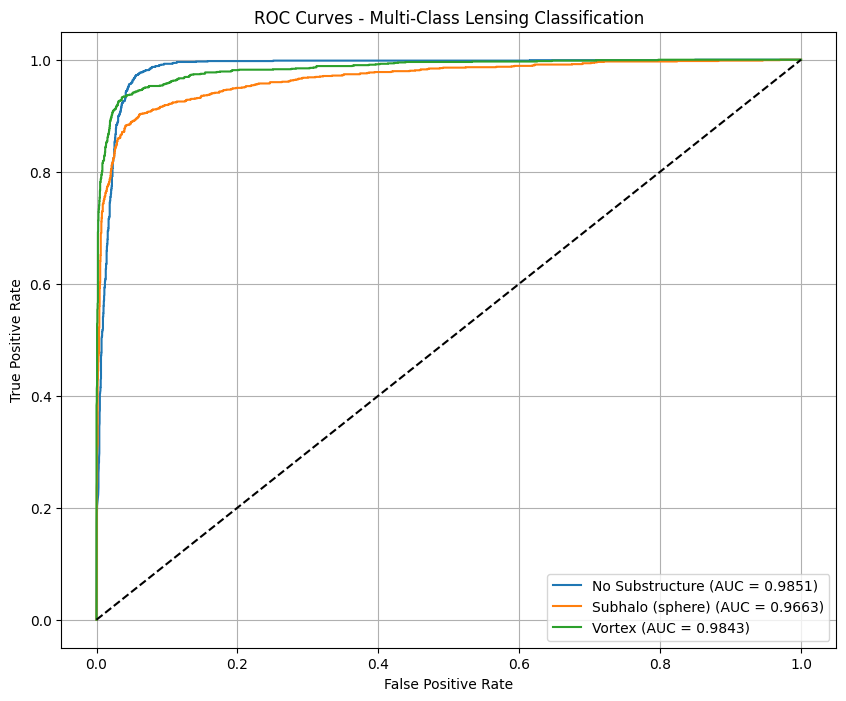

Macro AUC: 0.9786


In [ ]:
model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Per-class ROC curves
class_names = ['No Substructure', 'Subhalo (sphere)', 'Vortex']
plt.figure(figsize=(10, 8))

for i, name in enumerate(class_names):
    binary_labels = (all_labels == i).astype(int)
    fpr, tpr, _ = roc_curve(binary_labels, all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Multi-Class Lensing Classification')
plt.legend()
plt.grid(True)
plt.show()

# Overall AUC
macro_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
print(f"Macro AUC: {macro_auc:.4f}")